# Import Packages

In [7]:
!pip install numpy
!pip install opencv-contrib-python
!pip install tensorflow
!pip install tqdm
!pip install matplotlib
!pip install seaborn
!pip install pandas

# LOADING LIBRARIES

In [8]:
!pip install scikit-learn
import numpy as np
import os
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from tqdm import tqdm

# Enable inline plotting for Jupyter Notebook
%matplotlib inline


In [9]:

class_names =['Apple Apple_scab', 'Apple Black_rot', 'Apple healthy', 'Cherry healthy', 'Cherry Powdery_mildew', 'Corn healthy', 'Corn Northern_Leaf_Blight', 'Potato Early blight', 'Potato healthy', 'Potato Late_blight', 'Rice brown spot', 'Ricecrop healthy', 'Tomato Early_blight', 'Tomato healthy']
class_names_label = {class_name: i for i, class_name in enumerate(class_names)}
nb_classes = len(class_names)

# Image size
IMAGE_SIZE = (150, 150)

# LOADING DATABASE AND PRE-PROCESS

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 1016 images belonging to 14 classes.
Found 1016 images belonging to 14 classes.


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.1299 - loss: 2.6461 - val_accuracy: 0.2470 - val_loss: 2.4160
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.2677 - loss: 2.2558 - val_accuracy: 0.3671 - val_loss: 1.9047
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4537 - loss: 1.7313 - val_accuracy: 0.7067 - val_loss: 1.2575
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.5482 - loss: 1.4175 - val_accuracy: 0.7411 - val_loss: 0.9565
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6102 - loss: 1.1943 - val_accuracy: 0.6978 - val_loss: 0.9461
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.6683 - loss: 1.0631 - val_accuracy: 0.8602 - val_loss: 0.5637
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.7096 - loss: 0.8730 - val_accuracy: 0.8514 - val_loss: 0.5481
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.7451 - loss: 0.7987 - val_accuracy: 0.9045 - val_loss:

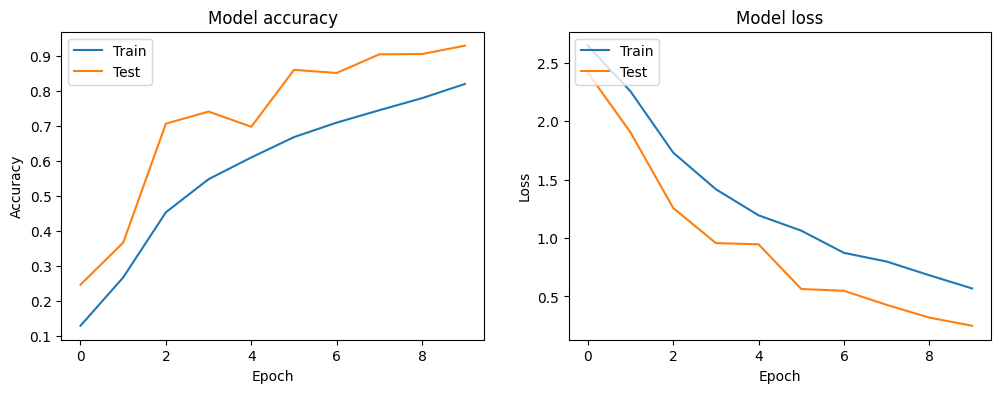

32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 421ms/step - accuracy: 0.9291 - loss: 0.2493


Test accuracy: 0.9291


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(nb_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_generator, epochs=10, validation_data=test_generator)
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc:.4f}')
model.save('plant_disease_model.h5')

In [12]:

train_images, train_labels = shuffle(train_images, train_labels, random_state=25)


print(f"Number of training examples: {train_labels.shape[0]}")
print(f"Number of testing examples: {test_labels.shape[0]}")
print(f"Each image is of size: {IMAGE_SIZE}")


NameError: name 'train_images' is not defined

# DATA VISUALIZATION

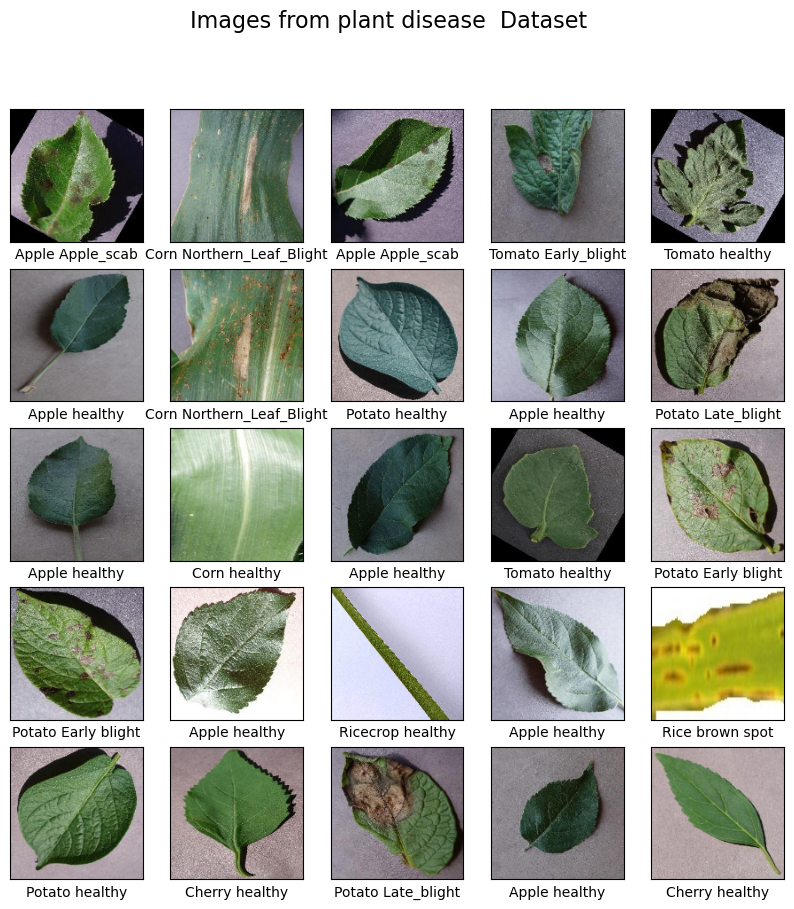

In [ ]:

def display_examples(images, labels):
    fig = plt.figure(figsize=(10, 10))
    fig.suptitle(" Images from plant disease  Dataset", fontsize=16)

    for i in range(25):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i])
        plt.xlabel(class_names[labels[i]])

    plt.show()

# Display sample images
display_examples(train_images, train_labels)


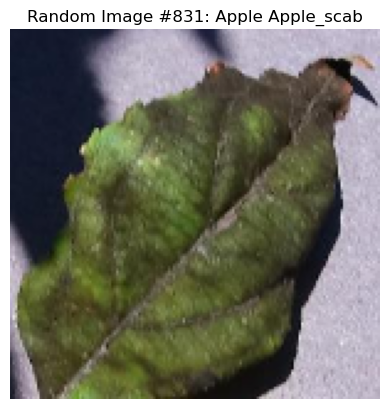

In [ ]:
# Display random image from the dataset
def show_random_image(class_labels, images, labels):
    idx = np.random.randint(images.shape[0])
    plt.figure()
    plt.imshow(images[idx])
    plt.title(f"Random Image #{idx}: {class_labels[labels[idx]]}")
    plt.axis('off')
    plt.show()


show_random_image(class_names, train_images, train_labels)


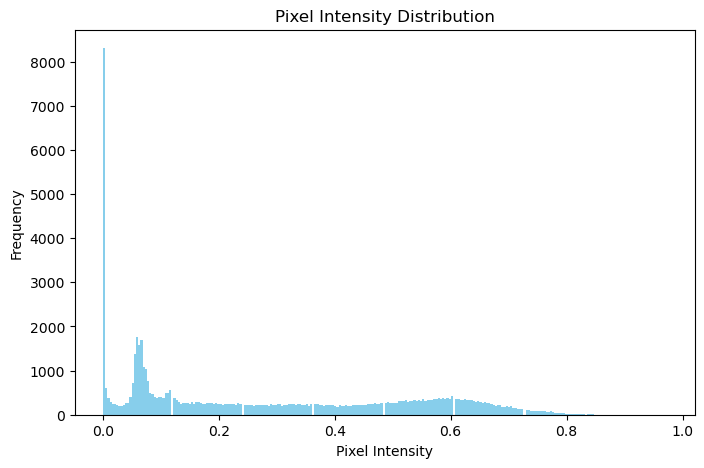

In [ ]:
def plot_pixel_intensity_histogram(image):
    plt.figure(figsize=(8, 5))
    plt.hist(image.ravel(), bins=256, color='skyblue')
    plt.title('Pixel Intensity Distribution')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    plt.show()


plot_pixel_intensity_histogram(train_images[0])


C:\Users\alex\AppData\Local\Temp\ipykernel_1360\1848522274.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Labels', y='Feature', palette='muted')


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

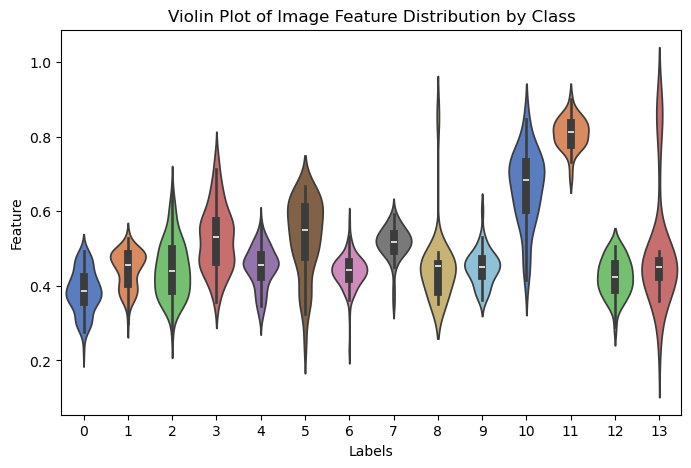

In [ ]:
import pandas as pd
import seaborn as sns

df = pd.DataFrame({'Labels': train_labels, 'Feature': [np.mean(img) for img in train_images]})
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Labels', y='Feature', palette='muted')
plt.title('Violin Plot of Image Feature Distribution by Class')
plt.show()


<Figure size 800x500 with 0 Axes>

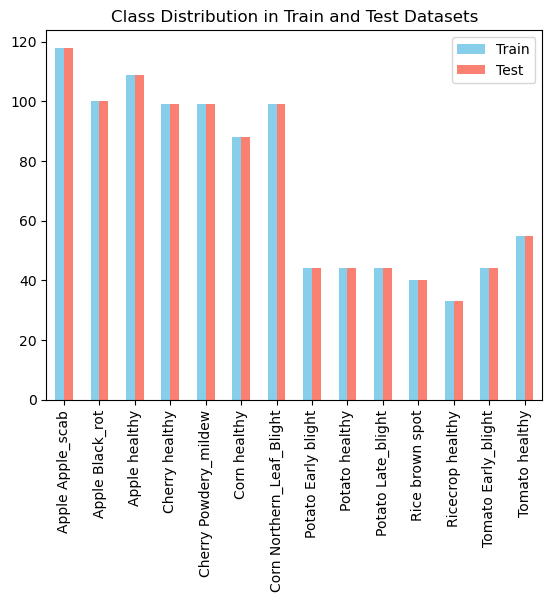

In [ ]:

_, train_class_counts = np.unique(train_labels, return_counts=True)
_, test_class_counts = np.unique(test_labels, return_counts=True)

# Bar Plot
plt.figure(figsize=(8, 5))
pd.DataFrame({'Train': train_class_counts, 'Test': test_class_counts}, index=class_names).plot.bar(color=['skyblue', 'salmon'])
plt.title('Class Distribution in Train and Test Datasets')
plt.show()


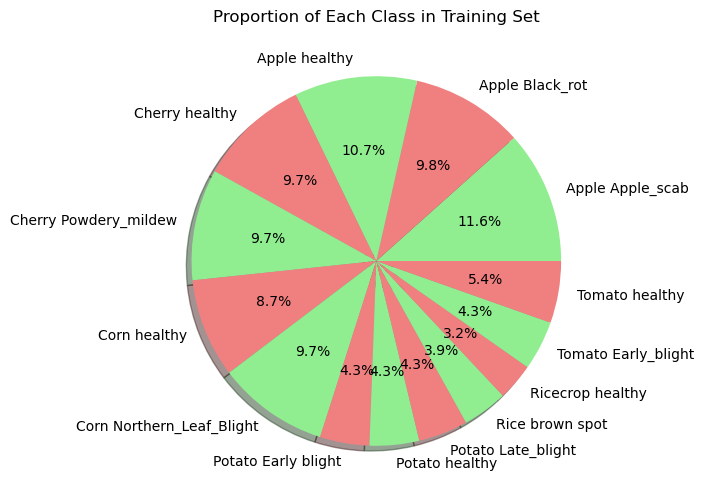

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(train_class_counts, labels=class_names, autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'], shadow=True)
plt.title('Proportion of Each Class in Training Set')
plt.show()


# MODEL

In [ ]:

cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(14, activation='softmax')  # Adjusted output layer for 2 classes
])


cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


history = cnn_model.fit(train_images, train_labels, batch_size=15, epochs=10, validation_split=0.2)


Epoch 1/10


C:\Users\alex\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 131ms/step - accuracy: 0.2820 - loss: 2.2539 - val_accuracy: 0.5294 - val_loss: 1.6050
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.6195 - loss: 1.2417 - val_accuracy: 0.6029 - val_loss: 1.2622
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.7672 - loss: 0.7648 - val_accuracy: 0.6716 - val_loss: 0.9661
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.8904 - loss: 0.3806 - val_accuracy: 0.6814 - val_loss: 1.0295
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.9495 - loss: 0.1613 - val_accuracy: 0.6814 - val_loss: 1.0997
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.9557 - loss: 0.1768 - val_accuracy: 0.7402 - val_loss: 1.0371
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.9889 - loss: 0.0556 - val_accuracy: 0.7353 - val_loss: 1.0883
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - accuracy: 0.9975 - loss: 0.0215 - val_accuracy: 0.7941 - val_

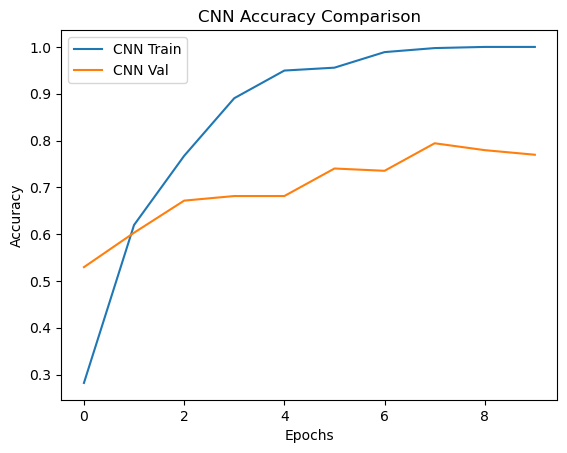

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy Comparison')
plt.legend(['CNN Train', 'CNN Val'])
plt.show()


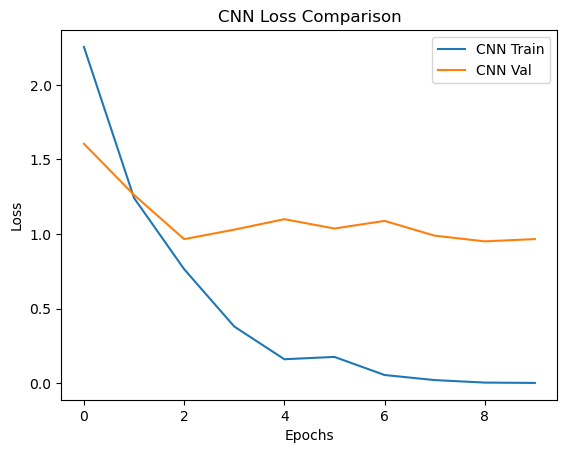

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss Comparison')
plt.legend(['CNN Train', 'CNN Val'])
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


y_pred_probs = cnn_model.predict(test_images)


y_pred = np.argmax(y_pred_probs, axis=1)


class_names = list(class_names_label.keys())


print("\n Classification Report:\n")
print(
    classification_report(
        test_labels,
        y_pred,
        target_names=class_names,
        digits=4
    )
)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step 

 Classification Report:

                           precision    recall  f1-score   support

         Apple Apple_scab     0.9167    0.9322    0.9244       118
          Apple Black_rot     0.9579    0.9100    0.9333       100
            Apple healthy     0.9099    0.9266    0.9182       109
           Cherry healthy     0.9612    1.0000    0.9802        99
    Cherry Powdery_mildew     0.9703    0.9899    0.9800        99
             Corn healthy     0.9886    0.9886    0.9886        88
Corn Northern_Leaf_Blight     0.9899    0.9899    0.9899        99
      Potato Early blight     0.9302    0.9091    0.9195        44
           Potato healthy     0.8837    0.8636    0.8736        44
       Potato Late_blight     0.9535    0.9318    0.9425        44
          Rice brown spot     1.0000    1.0000    1.0000        40
         Ricecrop healthy     1.0000    0.9697    0.9846        33
      Tomato Early_blight     0.9535    0.9318    0.9425     

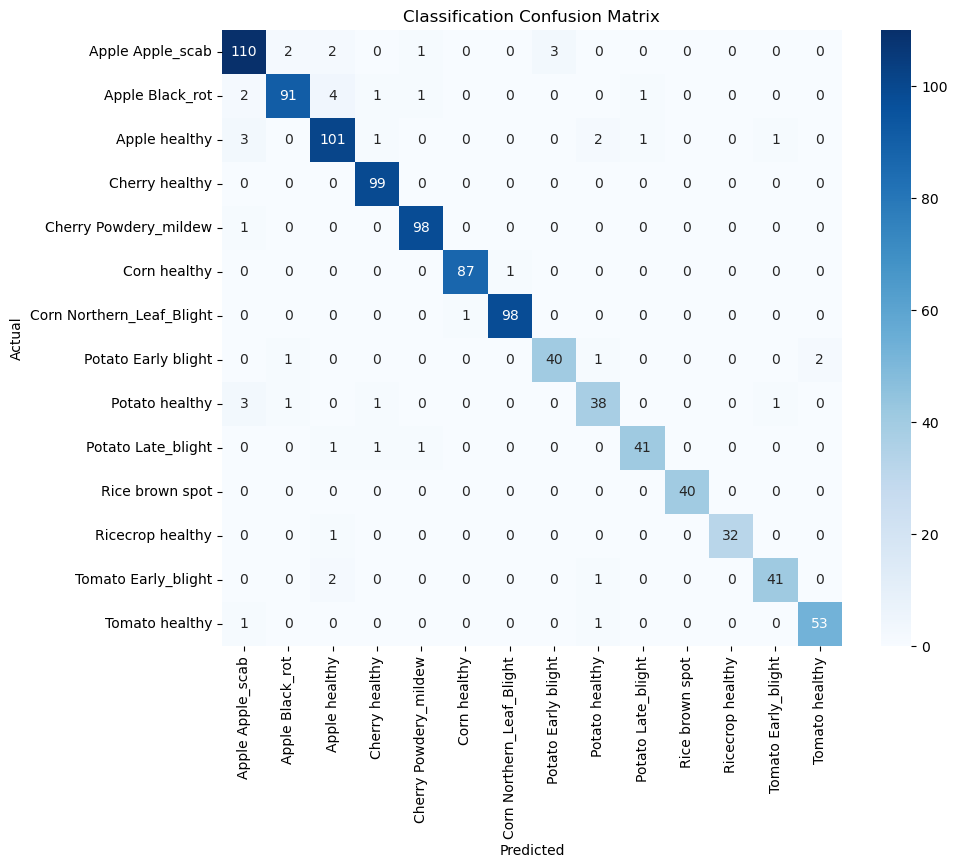

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Classification Confusion Matrix")
plt.show()


In [ ]:

cnn_model.save("cnn_model1.h5")

model_json = cnn_model.to_json()
with open("cnn_model1.json", "w") as json_file:
    json_file.write(model_json)

print("Model saved as 'cnn_model1.h5' and 'cnn_model1.json'.")


Model saved as 'cnn_model1.h5' and 'cnn_model1.json'.
